## Overview

- This notebook consolidates raw sensor logs from a tomato irrigation experiment with three lines—**L100**, **L60**, **L30**—corresponding to ~100%, ~60%, and ~30% of the Irriframe recommendation.
- We align timestamps, standardize units, validate monotonic irrigation counters, and remove duplicates/out-of-range readings to produce a single, tidy **long-format** table (`long_format_data.csv`) that the modeling notebook consumes. 
- Two domain constraints guide cleaning and interpretation: 
    - (1) an early phase where all lines were irrigated at **L100 until flowering** *(until ~July 14)* (cross-line comparisons there are not meaningful), 
    - (2) **two sensor-repositioning events** *(at July 12 and July 24)* after which data are considered reliable; analyses default to the post-second-event window. 
- The final schema includes `dt`, `line`, environment (`co2_env`, `humidity_env`, `temperature_env`, `pressure_env`), soil probe (`humidity`, `temperature`, `electrical_conductivity`), and `current_volume`. 



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
indicators_df = pd.read_csv('indicators.csv')
env_df = pd.read_csv('stuard_environmental_data.csv')
soil_df = pd.read_csv('stuard_soil_data.csv')
water_meter_df = pd.read_csv('stuard_water_meter_data.csv')

In [4]:
print("Indicators DataFrame:")
indicators_df.info()  # Display information about the indicators DataFrame
print("\nEnvironmental DataFrame:")
env_df.info()  # Display information about the environmental data DataFrame
print("\nSoil DataFrame:")
soil_df.info()  # Display information about the soil data DataFrame
print("\nWater Meter DataFrame:")
water_meter_df.info()  # Display information about the water meter data DataFrame

Indicators DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              77 non-null     float64
 1   gdd                     77 non-null     float64
 2   standard_day_degree     77 non-null     float64
 3   daily_mean_temperature  77 non-null     float64
 4   daily_max_above_Tbase   77 non-null     float64
 5   daily_max               77 non-null     float64
 6   daily_max_reduction     77 non-null     float64
 7   ontario_units           77 non-null     float64
dtypes: float64(8)
memory usage: 4.9 KB

Environmental DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10962 entries, 0 to 10961
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10962 non-null  int64  
 1   device_identifier  1096

In [5]:
indicators_df.describe()  # Display basic statistics of the indicators DataFrame

,Unnamed: 0,gdd,standard_day_degree,daily_mean_temperature,daily_max_above_Tbase,daily_max,daily_max_reduction,ontario_units
count,7.700000e+01,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,1.691273e+12,486.479221,17.180519,27.180519,26.659740,36.659740,16.851948,25.966039
std,1.932928e+09,272.935630,2.777757,2.777757,3.617293,3.617293,2.869238,2.007769
min,1.687990e+12,13.000000,9.500000,19.500000,14.600000,24.600000,10.300000,21.123000
25%,1.689631e+12,265.000000,15.050000,25.050000,24.500000,34.500000,14.900000,24.762000
50%,1.691273e+12,497.500000,17.150000,27.150000,27.000000,37.000000,17.000000,25.947000
75%,1.692914e+12,742.000000,19.300000,29.300000,29.100000,39.100000,19.400000,27.272000
max,1.694556e+12,905.400000,22.700000,32.700000,33.700000,43.700000,21.900000,30.496000


In [6]:
env_df.describe()  # Display basic statistics of the environmental data DataFrame

,id,ts_generation,co2,humidity,pressure,temperature,battery
count,10962.000000,1.096200e+04,10962.000000,10962.000000,10962.000000,10962.000000,74.0
mean,114774.051086,1.691341e+12,481.334793,58.067734,1009.798887,26.917734,100.0
std,53782.921798,1.905027e+09,48.004063,18.225084,5.249122,7.235252,0.0
min,70.000000,1.688044e+12,396.000000,18.000000,993.700000,10.100000,100.0
25%,68734.750000,1.689691e+12,448.000000,42.500000,1006.700000,20.800000,100.0
50%,111651.500000,1.691339e+12,470.000000,57.250000,1010.500000,26.100000,100.0
75%,162177.500000,1.692990e+12,503.000000,74.000000,1013.600000,33.100000,100.0
max,210060.000000,1.694642e+12,858.000000,97.000000,1019.400000,43.700000,100.0


In [7]:
soil_df.describe()  # Display basic statistics of the soil data DataFrame

,id,ts_generation,device_identifier,line,electrical_conductivity,humidity,temperature,battery
count,32668,32668,32668,32668,32668,32668,32668,228
unique,32667,32667,4,4,1393,646,132,3
top,id,ts_generation,91738f0250e567c5c673d2217596991d2eec0cc6da56ca...,1,141,20.59,23.2,100
freq,2,2,10966,10966,476,337,850,207


In [8]:
water_meter_df.describe()  # Display basic statistics of the water meter data DataFrame

,id,ts_generation,device_identifier,line,current_volume
count,32649,32649,32649,32649,32649
unique,32648,32647,4,4,1764
top,id,1693681633768,c733ec31aff4605215b6a5fba926aaae8cf58133bb1f6d...,3,15094
freq,2,2,10941,10941,2751


In [9]:
# Convert 'Unnamed: 0' column in indicators_df to datetime, localize to UTC, convert to Europe/Rome timezone, and remove timezone info
indicators_df['dt'] = pd.to_datetime(indicators_df['Unnamed: 0'], unit='ms', utc=True).dt.tz_convert('Europe/Rome').dt.tz_localize(None)
# Set 'dt' as the index of indicators_df
indicators_df.set_index('dt', inplace=True)

# For each environmental, soil, and water meter DataFrame:
for df in (env_df, soil_df, water_meter_df):
    # Convert 'ts_generation' column to datetime, localize to UTC, convert to Europe/Rome timezone, and remove timezone info
    df['dt'] = pd.to_datetime(df['ts_generation'], unit='ms', errors='coerce', utc=True).dt.tz_convert('Europe/Rome').dt.tz_localize(None)
    # Drop rows where 'dt' is missing
    df.dropna(subset=['dt'], inplace=True)
    # Sort DataFrame by 'dt'
    df.sort_values('dt', inplace=True)


C:\Users\Ariel\AppData\Local\Temp\ipykernel_33160\4257893610.py:9: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['dt'] = pd.to_datetime(df['ts_generation'], unit='ms', errors='coerce', utc=True).dt.tz_convert('Europe/Rome').dt.tz_localize(None)
C:\Users\Ariel\AppData\Local\Temp\ipykernel_33160\4257893610.py:9: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['dt'] = pd.to_datetime(df['ts_generation'], unit='ms', errors='coerce', utc=True).dt.tz_convert('Europe/Rome').dt.tz_local

# PRE PROCESSING

In [10]:
# Drop unnecessary columns from soil_df
soil_df.drop(columns=['ts_generation', 'id', 'device_identifier', 'battery'], inplace=True, errors='ignore')

# Drop unnecessary columns from water_meter_df
water_meter_df.drop(columns=['ts_generation', 'id', 'device_identifier', 'battery'], inplace=True, errors='ignore')

# Drop unnecessary columns from env_df
env_df.drop(columns=['ts_generation', 'id', 'device_identifier', 'battery'], inplace=True, errors='ignore')

# Drop the 'Unnamed: 0' column from indicators_df
indicators_df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [11]:
# Convert soil_df columns to appropriate data types
soil_df['line'] = soil_df['line'].astype(int)  # Ensure 'line' is integer
soil_df['electrical_conductivity'] = soil_df['electrical_conductivity'].astype(int)  # Ensure 'electrical_conductivity' is integer
soil_df['humidity'] = soil_df['humidity'].astype(float)  # Ensure 'humidity' is float
soil_df['temperature'] = soil_df['temperature'].astype(float)  # Ensure 'temperature' is float

# Convert water_meter_df columns to appropriate data types
water_meter_df['line'] = water_meter_df['line'].astype(int)  # Ensure 'line' is integer
water_meter_df['current_volume'] = water_meter_df['current_volume'].astype(int)  # Ensure 'current_volume' is integer

# Convert env_df columns to appropriate data types
env_df['co2'] = env_df['co2'].astype(int)  # Ensure 'co2' is integer
env_df['humidity'] = env_df['humidity'].astype(float)  # Ensure 'humidity' is float
env_df['temperature'] = env_df['temperature'].astype(float)  # Ensure 'temperature' is float
env_df['pressure'] = env_df['pressure'].astype(float)  # Ensure 'pressure' is float


# WATER

In [12]:
L100_water = water_meter_df[water_meter_df['line'] == 1].copy()  # Filter for line 1 water meter data
L60_water = water_meter_df[water_meter_df['line'] == 2].copy()  # Filter for line 2 water meter data
L30_water = water_meter_df[water_meter_df['line'] == 3].copy()  # Filter for line 3 water meter data

L100_water.drop(columns=['line'], inplace=True)  # Drop 'line' column from line 1 water meter data
L60_water.drop(columns=['line'], inplace=True)  # Drop 'line' column from line 2 water meter data
L30_water.drop(columns=['line'], inplace=True)  # Drop 'line' column from

L100_water['dt'] = pd.to_datetime(L100_water['dt'])
L60_water['dt'] = pd.to_datetime(L60_water['dt'])
L30_water['dt'] = pd.to_datetime(L30_water['dt'])

In [13]:
import pandas as pd

import plotly.graph_objects as go

# ensure datetime dtype
x1 = pd.to_datetime(L100_water['dt'])
x2 = pd.to_datetime(L60_water['dt'])
x3 = pd.to_datetime(L30_water['dt'])

fig = go.Figure()
fig.add_trace(go.Scatter(x=x1, y=L100_water['current_volume'], mode='lines', name='L100'))
fig.add_trace(go.Scatter(x=x2, y=L60_water['current_volume'], mode='lines', name='L60'))
fig.add_trace(go.Scatter(x=x3, y=L30_water['current_volume'], mode='lines', name='L30'))

fig.update_layout(
    title='Water Meters: Current Volume over Time',
    xaxis_title='Datetime',
    yaxis_title='Current Volume',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=500,
    hovermode='x unified'
)
fig.update_xaxes(rangeslider_visible=False)
fig.show()

In [14]:
L100_water['delta'] = L100_water['dt'].diff()  # Calculate the time difference for line 1
L60_water['delta'] = L60_water['dt'].diff()  # Calculate the time difference for line 2
L30_water['delta'] = L30_water['dt'].diff()  # Calculate the time difference for line 3
period = pd.Timedelta(minutes=10)  # Define the period for calculating intervals
L100_water['n_interval'] = (L100_water['delta'] / period).round().fillna(0).astype(int)  # Calculate the number of intervals for line 1
L60_water['n_interval'] = (L60_water['delta'] / period).round().fillna(0).astype(int)  # Calculate the number of intervals for line 2
L30_water['n_interval'] = (L30_water['delta'] / period).round().fillna(0).astype(int)  # Calculate the number of intervals for line 3

In [15]:
assigned_water_line1 = []  # Initialize the list to store assigned timestamps for line 1
baseline_water_line1 = L100_water['dt'].iloc[0].round('10min')  # Round the first timestamp to the nearest 10 minutes for line 1
assigned_water_line1.append(baseline_water_line1)  # Add the baseline timestamp to the list

assigned_water_line2 = []  # Initialize the list to store assigned timestamps for line 2
baseline_water_line2 = L60_water['dt'].iloc[0].round('10min')  # Round the first timestamp to the nearest 10 minutes for line 2
assigned_water_line2.append(baseline_water_line2)  # Add the baseline timestamp to the list

assigned_water_line3 = []  # Initialize the list to store assigned timestamps for line 3
baseline_water_line3 = L30_water['dt'].iloc[0].round('10min')  # Round the first timestamp to the nearest 10 minutes for line 3
assigned_water_line3.append(baseline_water_line3)  # Add the baseline timestamp to the list

In [16]:
# Assign calculated timestamps to each row for line 1 water meter data
for n in L100_water['n_interval'].iloc[1:]:  # Iterate over the number of intervals (skip the first, which is baseline)
    assigned_water_line1.append(assigned_water_line1[-1] + n * period)  # Add n * period to the last assigned timestamp
L100_water['assigned_dt'] = assigned_water_line1  # Assign the calculated timestamps to a new column

# Repeat for line 2 water meter data
for n in L60_water['n_interval'].iloc[1:]:
    assigned_water_line2.append(assigned_water_line2[-1] + n * period)
L60_water['assigned_dt'] = assigned_water_line2

# Repeat for line 3 water meter data
for n in L30_water['n_interval'].iloc[1:]:
    assigned_water_line3.append(assigned_water_line3[-1] + n * period)
L30_water['assigned_dt'] = assigned_water_line3

In [17]:
def gap_align(df_line, line_id='' , value_cols='', tag=''):
    """
    Align a time series to a regular 10-minute grid, carry selected value columns,
    and add a binary missing indicator column.

    Parameters:
        df_line (pd.DataFrame): Input DataFrame containing an 'assigned_dt' column and value columns.
        line_id (int|str, optional): Line identifier used to suffix column names (e.g., _L1). If empty,
                                     the tag is used as suffix for value columns.
        value_cols (list[str]): Columns to keep and align on the time grid.
        tag (str): Short label used in the missing indicator column name (e.g., 'water', 'soil', 'env').

    Returns:
        pd.DataFrame: DataFrame with:
            - 'dt' as the regular 10-minute datetime index column,
            - aligned value columns with suffixes,
            - a '{tag}_missing[_L{line_id}]' column indicating rows with any missing value.
    """
    # Keep only the requested value columns, indexed by the aligned timestamp
    out = df_line.set_index('assigned_dt')[value_cols].sort_index()

    # Build a full 10-minute grid between the first and last timestamps present
    full = pd.date_range(out.index.min(), out.index.max(), freq='10min')

    # Reindex to the full grid; 'dt' becomes the index name for merging later
    out = out.reindex(full).rename_axis('dt')

    # Suffix value columns by line when provided, otherwise by tag (env uses tag)
    suffix = f"_L{line_id}" if line_id else f"_{tag}"
    out.columns = [f'{column}{suffix}' for column in out.columns]

    # Add a missing indicator: 1 if any value column is NaN on that timestamp, else 0
    # For env (no line_id), the column is 'env_missing'; for others it's '<tag>_missing_L{line_id}'
    missing_suffix = f'_L{line_id}' if line_id else ''
    out[f'{tag}_missing{missing_suffix}'] = out.isna().any(axis=1).astype(int)
    
    # Return as a regular DataFrame with 'dt' as a column
    return out.reset_index()


In [18]:
water1 = gap_align(L100_water, 1, ['current_volume'],'water')
water2 = gap_align(L60_water, 2, ['current_volume'], 'water')
water3 = gap_align(L30_water, 3, ['current_volume'], 'water')


# END OF NEW WATER

# SOIL

In [19]:
L100_soil = soil_df[soil_df['line'] == 1].copy()  # Filter for line 1
L60_soil = soil_df[soil_df['line'] == 2].copy()  # Filter for line 2
L30_soil = soil_df[soil_df['line'] == 3].copy()  # Filter for line 3

L100_soil.drop(columns=['line'], inplace=True)  # Drop 'line' column from line 1 soil data
L60_soil.drop(columns=['line'], inplace=True)  # Drop 'line' column from line 2 soil data
L30_soil.drop(columns=['line'], inplace=True)  # Drop 'line' column from line 3 soil data


In [21]:
L100_soil['delta'] = L100_soil['dt'].diff()
L60_soil['delta'] = L60_soil['dt'].diff()
L30_soil['delta'] = L30_soil['dt'].diff()

In [22]:
period = pd.Timedelta(minutes=10)
L100_soil['n_interval'] = (
    (L100_soil['delta']/period).round().fillna(0).astype(int)  # Calculate the number of intervals and fill NaN with 0
)
L60_soil['n_interval'] = (
    (L60_soil['delta']/period).round().fillna(0).astype(int)  # Calculate the number of intervals and fill NaN with 0
)
L30_soil['n_interval'] = (
    (L30_soil['delta']/period).round().fillna(0).astype(int)  # Calculate the number of intervals and fill NaN with 0
)

In [23]:
assigned_line1 = []
baseline_line1 = L100_soil['dt'].iloc[0].round("10min")  # Round the baseline to the nearest 10 minutes
assigned_line1.append(baseline_line1)

assigned_line2 = []
baseline_line2 = L60_soil['dt'].iloc[0].round("10min")  #
assigned_line2.append(baseline_line2)

assigned_line3 = []
baseline_line3 = L30_soil['dt'].iloc[0].round("10min")
assigned_line3.append(baseline_line3)

In [24]:
for n in L100_soil['n_interval'].iloc[1:]:  # Skip the first element since it's the baseline
    assigned_line1.append(assigned_line1[-1] + period * n)
L100_soil['assigned_dt'] = assigned_line1  # Assign the calculated timestamps to a new column


for n in L60_soil['n_interval'].iloc[1:]:  # Skip the first element since it's the baseline
    assigned_line2.append(assigned_line2[-1] + period * n)
L60_soil['assigned_dt'] = assigned_line2  # Assign the calculated timestamps to a new column

for n in L30_soil['n_interval'].iloc[1:]:  # Skip the first element since it's the baseline
    assigned_line3.append(assigned_line3[-1] + period * n)
L30_soil['assigned_dt'] = assigned_line3  # Assign the calculated timestamps to a new column

In [25]:
soil1 = gap_align(L100_soil, 1, ['electrical_conductivity', 'humidity', 'temperature'], 'soil')
soil2 = gap_align(L60_soil, 2, ['electrical_conductivity', 'humidity', 'temperature'], 'soil')
soil3 = gap_align(L30_soil, 3, ['electrical_conductivity', 'humidity', 'temperature'], 'soil')

# END OF NEW SOIL

# ENV

In [26]:
env_df['delta'] = env_df['dt'].diff()  # Calculate the time difference
env_df['n_interval'] = (env_df['delta'] / period).round().fillna(0).astype(int)  # Calculate the number of intervals
assigned_env = []  # Initialize the list to store assigned timestamps
baseline_env = env_df['dt'].iloc[0].round('10min')  # Round the first timestamp to the nearest 10 minutes
assigned_env.append(baseline_env)  # Add the baseline timestamp to the list
for n in env_df['n_interval'].iloc[1:]:  # Iterate over the number of intervals (skip the first, which is baseline)
    assigned_env.append(assigned_env[-1] + n * period)  # Add n * period to the last assigned timestamp
env_df['assigned_dt'] = assigned_env  # Assign the calculated timestamps to a new column

In [27]:
env_df_aligned = gap_align(env_df, value_cols= ['co2', 'humidity', 'temperature', 'pressure'], tag='env')

# COMBINING WATER ,SOIL AND ENV DATA

In [28]:
# List of aligned DataFrames to be merged
frames = [water1, water2, water3, soil1, soil2, soil3, env_df_aligned]

# Find the earliest timestamp across all DataFrames
start = min(df['dt'].min() for df in frames)

# Find the latest timestamp across all DataFrames
end = max(df['dt'].max() for df in frames)

# Create a global time grid with 10-minute intervals from start to end
global_grid = pd.DataFrame({'dt': pd.date_range(start, end, freq='10min')})



In [29]:
# Initialize global_df as a copy of the global time grid (10-minute intervals)
global_df = global_grid.copy()

# For each aligned DataFrame (water, soil, env):
for df in frames:
    # Sort by 'dt' and drop duplicate timestamps, keeping the last occurrence
    df = df.sort_values('dt').drop_duplicates('dt', keep='last')
    # Merge the current DataFrame into global_df on 'dt', using a left join to preserve the full time grid
    global_df = global_df.merge(df, on='dt', how='left')

In [30]:
# Find the first row in global_df where there are no missing values (i.e., all columns are complete)
first_complete_row = global_df.dropna().iloc[0]

# Print the first complete row
print(first_complete_row)

dt                            2023-06-29 18:10:00
current_volume_L1                           154.0
water_missing_L1                              0.0
current_volume_L2                           165.0
water_missing_L2                                0
current_volume_L3                             0.0
water_missing_L3                              0.0
electrical_conductivity_L1                  517.0
humidity_L1                                 23.35
temperature_L1                               28.3
soil_missing_L1                               0.0
electrical_conductivity_L2                  726.0
humidity_L2                                 31.35
temperature_L2                               28.5
soil_missing_L2                               0.0
electrical_conductivity_L3                 1022.0
humidity_L3                                 44.38
temperature_L3                               27.7
soil_missing_L3                               0.0
co2_env                                     449.0


In [31]:
# Filter global_df to include only rows where 'dt' is greater than or equal to the first complete row's 'dt'
# This ensures that all columns have complete (non-missing) data from this point onward
global_df_cut = global_df[global_df['dt'] >= first_complete_row['dt']].reset_index(drop=True)

In [32]:
# Extract the date (day) from the 'dt' column in global_df_cut and store it in a new 'date' column
global_df_cut['date'] = global_df_cut['dt'].dt.date

# Reset the index of indicators_df and rename the 'dt' column to 'date' for merging
indicators_df_reset = indicators_df.reset_index().rename(columns={'dt': 'date'})

# Ensure the 'date' column in indicators_df_reset is in the same date format as global_df_cut
indicators_df_reset['date'] = indicators_df_reset['date'].dt.date

In [33]:
indicators_df_reset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    77 non-null     object 
 1   gdd                     77 non-null     float64
 2   standard_day_degree     77 non-null     float64
 3   daily_mean_temperature  77 non-null     float64
 4   daily_max_above_Tbase   77 non-null     float64
 5   daily_max               77 non-null     float64
 6   daily_max_reduction     77 non-null     float64
 7   ontario_units           77 non-null     float64
dtypes: float64(7), object(1)
memory usage: 4.9+ KB


In [34]:
# Merge the two DataFrames on the 'date' column
combined_df = pd.merge(
    global_df_cut,  # DataFrame with aligned water, soil, and env data (with 'date' column)
    indicators_df_reset.rename(
        columns={col: f"{col}_yesterday" for col in indicators_df_reset.columns if col != 'date'}  # Rename columns except 'date' to indicate they are from indicators_df
    ),
    on='date',  # Merge on the 'date' column
    how='left'  # Use left join to keep all rows from global_df_cut
)
combined_df.drop(columns=['date'], inplace=True)  # Drop the 'date' column after merging


In [35]:
combined_df.to_csv('wide_format_data.csv', index=False)  # Save the combined DataFrame to a CSV file

# EDA


In [36]:
df = pd.read_csv('wide_format_data.csv')
# df.columns = df.columns.str.strip()

df = df[[col for col in df.columns if "missing" not in col]]

In [37]:
df['dt'] = pd.to_datetime(df['dt'])
df = df.set_index('dt')

### First Rows

In [38]:
df.head()



,current_volume_L1,current_volume_L2,current_volume_L3,electrical_conductivity_L1,humidity_L1,temperature_L1,electrical_conductivity_L2,humidity_L2,temperature_L2,electrical_conductivity_L3,...,humidity_env,temperature_env,pressure_env,gdd_yesterday,standard_day_degree_yesterday,daily_mean_temperature_yesterday,daily_max_above_Tbase_yesterday,daily_max_yesterday,daily_max_reduction_yesterday,ontario_units_yesterday
dt,,,,,,,,,,,,,,,,,,,,,
2023-06-29 18:10:00,154.0,165.0,0.0,517.0,23.35,28.3,726.0,31.35,28.5,1022.0,...,36.5,33.9,1009.1,13.0,22.2,32.2,31.2,41.2,12.8,27.984
2023-06-29 18:20:00,154.0,165.0,0.0,519.0,23.35,28.4,725.0,31.35,28.4,1023.0,...,37.0,33.9,1009.1,13.0,22.2,32.2,31.2,41.2,12.8,27.984
2023-06-29 18:30:00,154.0,165.0,0.0,521.0,23.35,28.5,726.0,31.35,28.4,1024.0,...,35.0,33.9,1009.2,13.0,22.2,32.2,31.2,41.2,12.8,27.984
2023-06-29 18:40:00,154.0,165.0,0.0,521.0,23.35,28.6,726.0,31.35,28.3,1024.0,...,34.5,33.9,1009.0,13.0,22.2,32.2,31.2,41.2,12.8,27.984
2023-06-29 18:50:00,154.0,165.0,0.0,522.0,23.35,28.7,727.0,31.21,28.3,1025.0,...,35.0,34.0,1009.0,13.0,22.2,32.2,31.2,41.2,12.8,27.984


### Basic information about the data types



In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10979 entries, 2023-06-29 18:10:00 to 2023-09-13 23:50:00
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   current_volume_L1                 10701 non-null  float64
 1   current_volume_L2                 10799 non-null  float64
 2   current_volume_L3                 10835 non-null  float64
 3   electrical_conductivity_L1        10858 non-null  float64
 4   humidity_L1                       10858 non-null  float64
 5   temperature_L1                    10858 non-null  float64
 6   electrical_conductivity_L2        10850 non-null  float64
 7   humidity_L2                       10850 non-null  float64
 8   temperature_L2                    10850 non-null  float64
 9   electrical_conductivity_L3        10838 non-null  float64
 10  humidity_L3                       10838 non-null  float64
 11  temperature_L3                  

In [40]:
# checking for null values
df.isnull().sum()

current_volume_L1                   278
current_volume_L2                   180
current_volume_L3                   144
electrical_conductivity_L1          121
humidity_L1                         121
temperature_L1                      121
electrical_conductivity_L2          129
humidity_L2                         129
temperature_L2                      129
electrical_conductivity_L3          141
humidity_L3                         141
temperature_L3                      141
co2_env                              36
humidity_env                         36
temperature_env                      36
pressure_env                         36
gdd_yesterday                         0
standard_day_degree_yesterday         0
daily_mean_temperature_yesterday      0
daily_max_above_Tbase_yesterday       0
daily_max_yesterday                   0
daily_max_reduction_yesterday         0
ontario_units_yesterday               0
dtype: int64

In [41]:
df.describe()

,current_volume_L1,current_volume_L2,current_volume_L3,electrical_conductivity_L1,humidity_L1,temperature_L1,electrical_conductivity_L2,humidity_L2,temperature_L2,electrical_conductivity_L3,...,humidity_env,temperature_env,pressure_env,gdd_yesterday,standard_day_degree_yesterday,daily_mean_temperature_yesterday,daily_max_above_Tbase_yesterday,daily_max_yesterday,daily_max_reduction_yesterday,ontario_units_yesterday
count,10701.000000,10799.000000,10835.000000,10858.000000,10858.000000,10858.000000,10850.000000,10850.000000,10850.000000,10838.000000,...,10943.000000,10943.000000,10943.000000,10979.000000,10979.000000,10979.000000,10979.000000,10979.000000,10979.000000,10979.000000
mean,23101.984768,15622.911103,9961.528380,335.092743,25.899731,23.363566,362.645714,25.484069,24.195014,425.434582,...,58.107192,26.901115,1009.798757,491.179944,17.130686,27.130686,26.614664,36.614664,16.892176,25.946005
std,13418.775120,8434.291599,4796.563173,136.819141,3.946772,1.804184,272.461199,8.086824,2.314133,360.167888,...,18.215764,7.229635,5.253624,268.356380,2.727524,2.727524,3.582956,3.582956,2.835912,1.994447
min,154.000000,165.000000,0.000000,0.000000,0.000000,19.600000,56.000000,2.020000,19.700000,0.000000,...,18.000000,10.100000,993.700000,13.000000,9.500000,19.500000,14.600000,24.600000,10.300000,21.123000
25%,9756.000000,7543.000000,5901.000000,238.000000,23.140000,22.000000,143.000000,19.350000,22.700000,165.000000,...,42.500000,20.800000,1006.700000,265.000000,15.050000,25.050000,24.500000,34.500000,14.900000,24.762000
50%,25991.000000,17647.000000,11319.000000,343.000000,25.120000,23.200000,248.000000,22.410000,23.900000,278.000000,...,57.500000,26.100000,1010.500000,497.500000,17.150000,27.150000,27.000000,37.000000,17.000000,25.947000
75%,35871.000000,25028.000000,15094.000000,423.000000,28.280000,24.400000,536.000000,30.122500,25.200000,552.000000,...,74.000000,33.100000,1013.600000,742.000000,19.300000,29.300000,29.100000,39.100000,19.400000,27.272000
max,38280.000000,25028.000000,15094.000000,1071.000000,40.710000,28.900000,1443.000000,53.560000,32.600000,1767.000000,...,97.000000,43.700000,1019.400000,905.400000,22.700000,32.700000,33.700000,43.700000,21.900000,30.496000


### Information about common sensor values


In [42]:
# Check distribution of sensor values
print(df['temperature_env'].value_counts().head(10))  # Most common temperatures
print(df['co2_env'].value_counts().head(10))          # Most common CO2 levels

temperature_env
22.0    81
19.8    76
32.4    74
32.3    72
18.7    72
23.4    71
34.1    70
19.6    69
22.7    68
21.8    68
Name: count, dtype: int64
co2_env
457.0    149
450.0    141
455.0    140
444.0    137
448.0    137
445.0    135
443.0    134
454.0    133
449.0    132
458.0    130
Name: count, dtype: int64


In [41]:
print(df['pressure_env'].value_counts().head(10)) # Most common air pressure

pressure_env
1012.3    139
1012.5    135
1012.6    129
1012.2    129
1009.7    128
1012.7    122
1009.3    118
1009.9    117
1009.5    107
1009.2    105
Name: count, dtype: int64


### Looking for duplicated entries


In [43]:
n_dups = df.duplicated().sum()
print(f'Found {n_dups} duplicate rows')

if n_dups > 0:
    display(df[df.duplicated(keep=False)])

Found 0 duplicate rows


### Boxplots

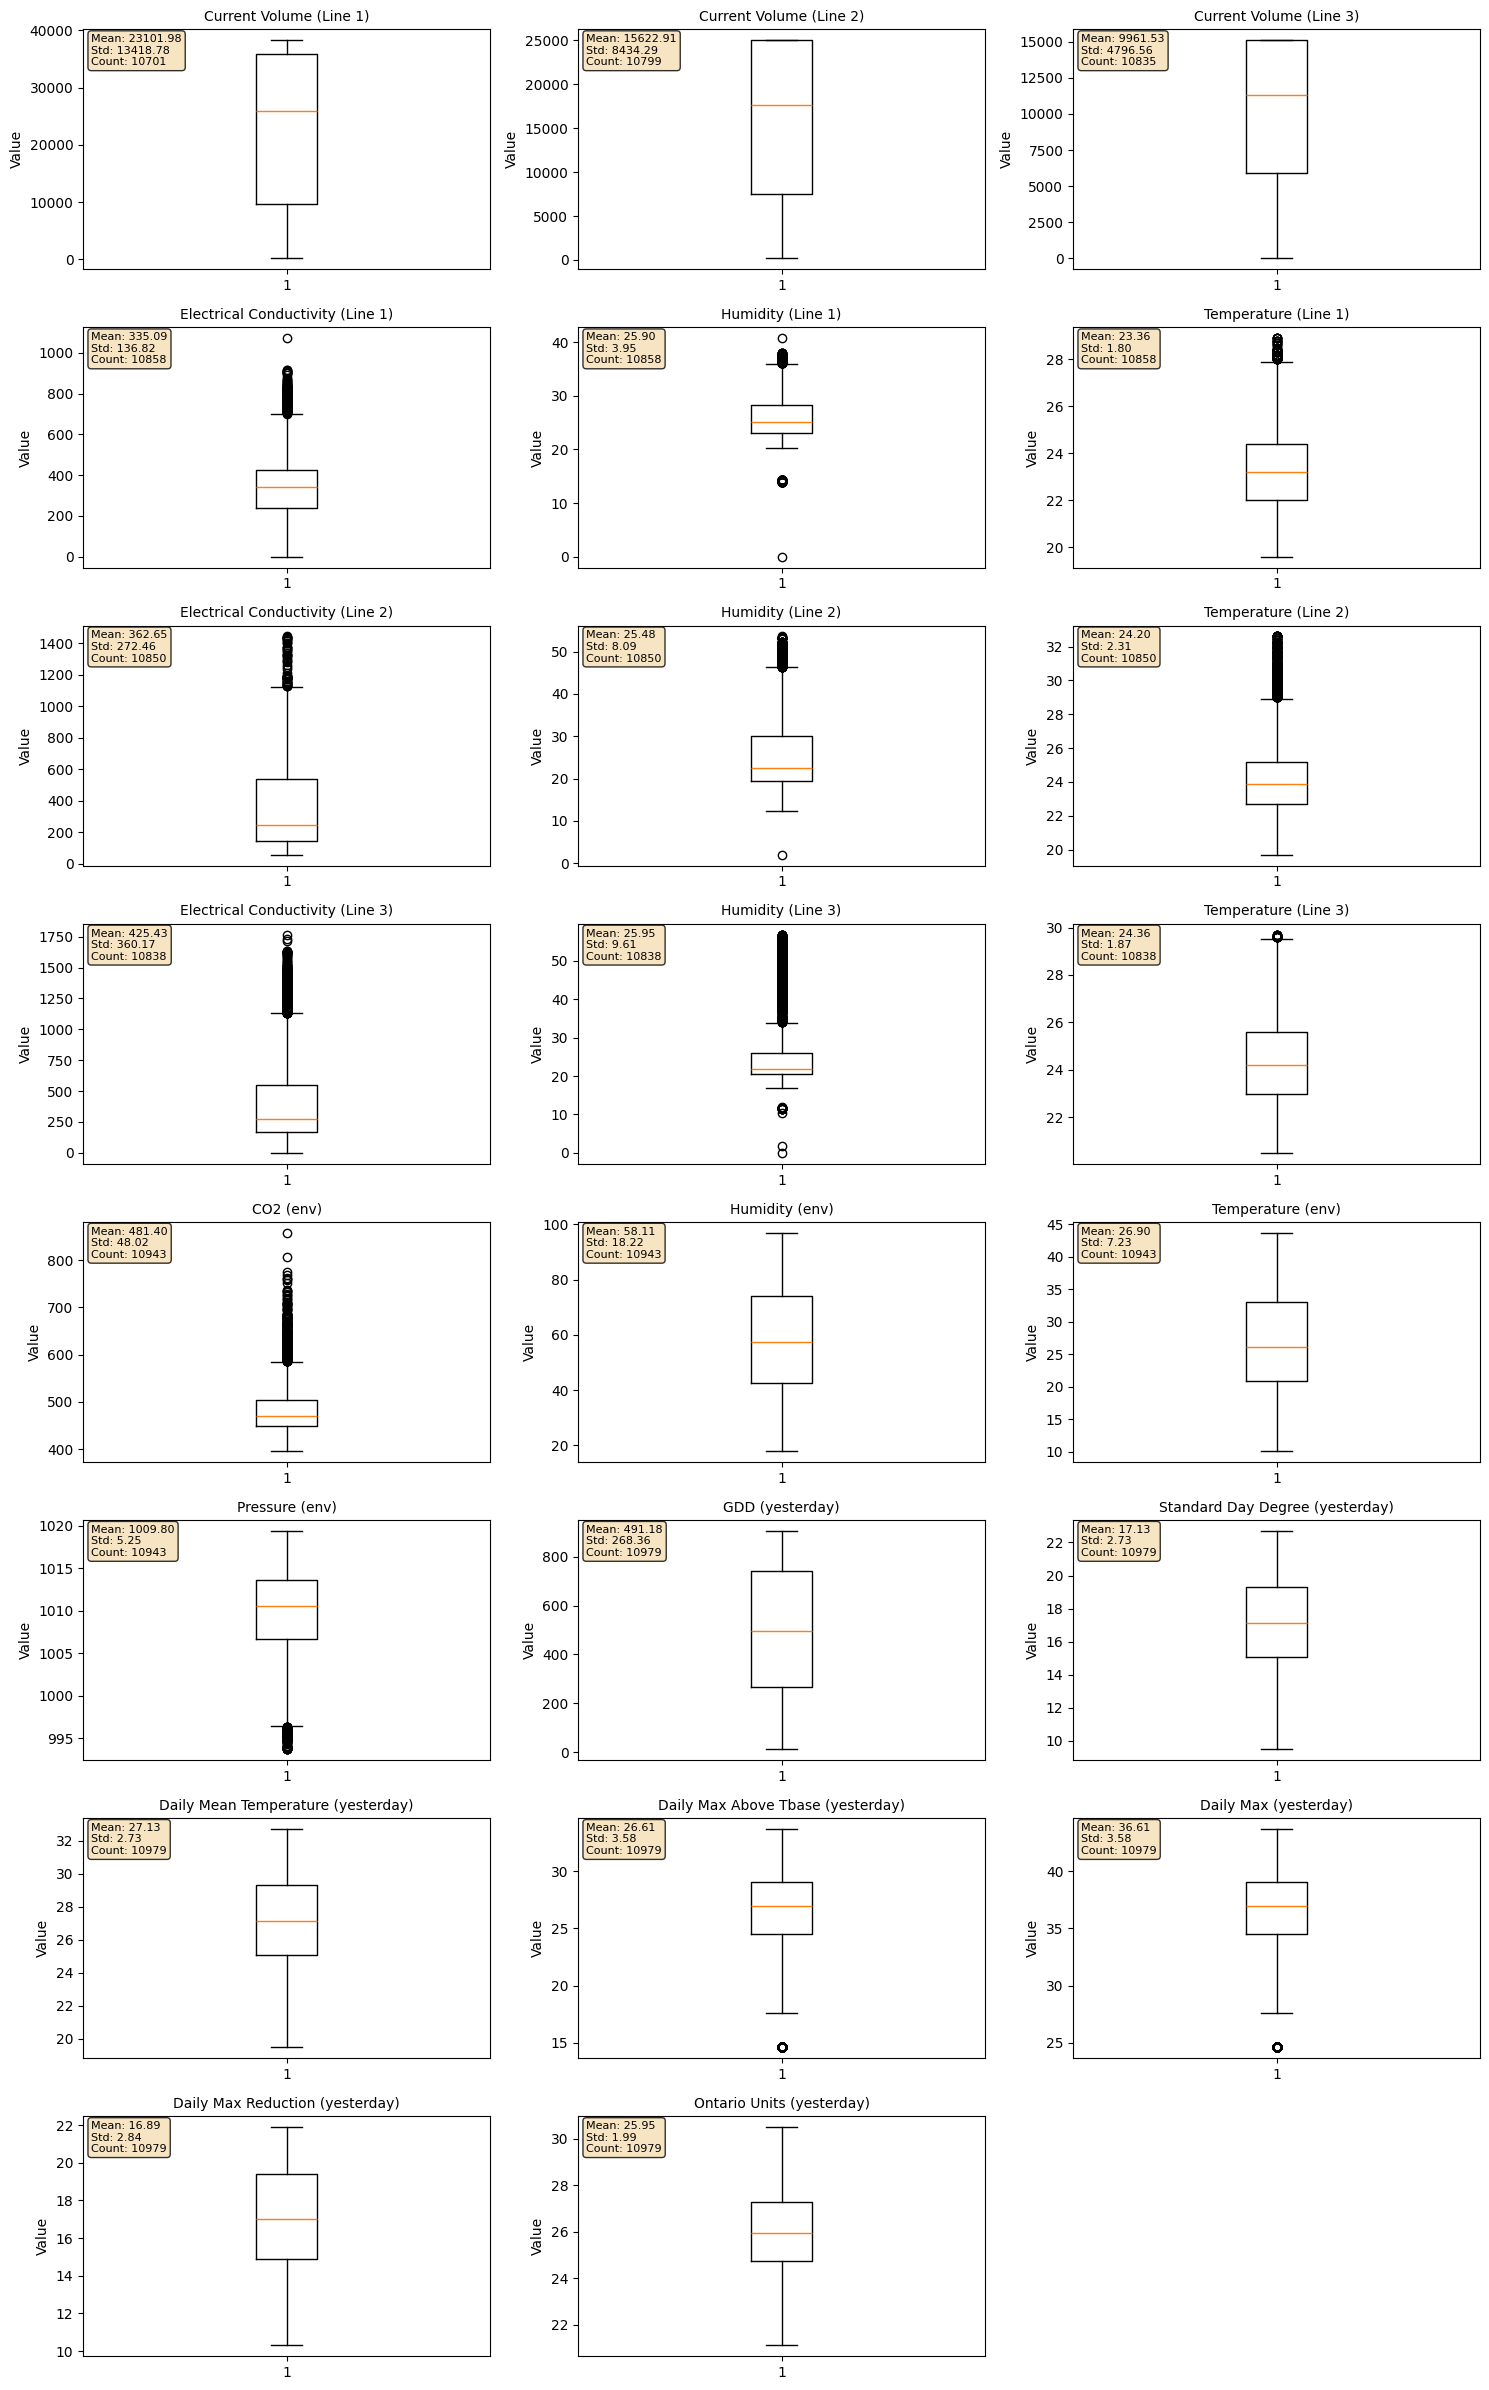

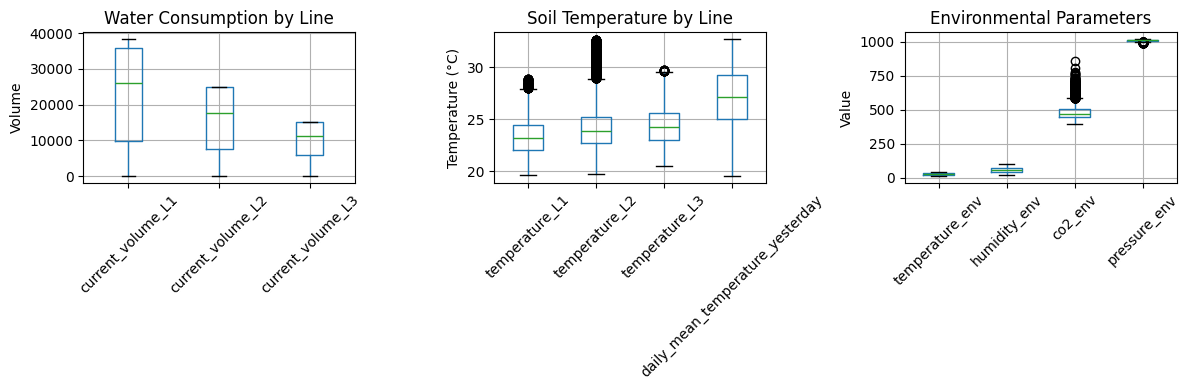

In [45]:
# Get numeric columns (excluding datetime)
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Create a simple column title mapping to avoid NameError and yield nicer plot titles
column_titles = {}
for col in numeric_cols:
    # Handle sensor line suffixes like _L1/_L2/_L3
    if col.endswith('_L1') or col.endswith('_L2') or col.endswith('_L3'):
        base, suffix = col.rsplit('_', 1)
        title = base.replace('_', ' ').title() + f' (Line {suffix[-1]})'
    # Environmental sensors
    elif col.endswith('_env'):
        base = col[:-4]
        title = base.replace('_', ' ').title() + ' (env)'
    # Yesterday indicators
    elif col.endswith('_yesterday'):
        base = col[:-10]
        title = base.replace('_', ' ').title() + ' (yesterday)'
    else:
        title = col.replace('_', ' ').title()
    # Minor cosmetic fixes
    title = title.replace('Co2', 'CO2').replace('Gdd', 'GDD')
    column_titles[col] = title


# Setup the plot
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    series = df[col].dropna()
    
    # Create boxplot
    ax.boxplot(series, vert=True, showfliers=True)
    
    # Set title using the mapping
    title = column_titles.get(col, col)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Value')
    
    # Add basic statistics as text
    stats_text = f'Mean: {series.mean():.2f}\nStd: {series.std():.2f}\nCount: {len(series)}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Remove empty subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Alternative: Simple boxplots by category
def plot_boxplots_by_category(df):
    """Plot boxplots organized by sensor type"""
    
    # Water data
    water_cols = [col for col in df.columns if 'current_volume' in col]
    if water_cols:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        df[water_cols].boxplot()
        plt.title('Water Consumption by Line')
        plt.ylabel('Volume')
        plt.xticks(rotation=45)
    
    # Soil data
    soil_temp_cols = [col for col in df.columns if 'temperature' in col and 'env' not in col]
    if soil_temp_cols:
        plt.subplot(1, 3, 2)
        df[soil_temp_cols].boxplot()
        plt.title('Soil Temperature by Line')
        plt.ylabel('Temperature (°C)')
        plt.xticks(rotation=45)
    
    # Environmental data
    env_cols = ['temperature_env', 'humidity_env', 'co2_env', 'pressure_env']
    if all(col in df.columns for col in env_cols):
        plt.subplot(1, 3, 3)
        df[env_cols].boxplot()
        plt.title('Environmental Parameters')
        plt.ylabel('Value')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Run the alternative visualization
plot_boxplots_by_category(df)


### ENVIRONMENTAL CONDITIONS BY HOUR

In [ ]:
df.reset_index('dt', inplace=True)


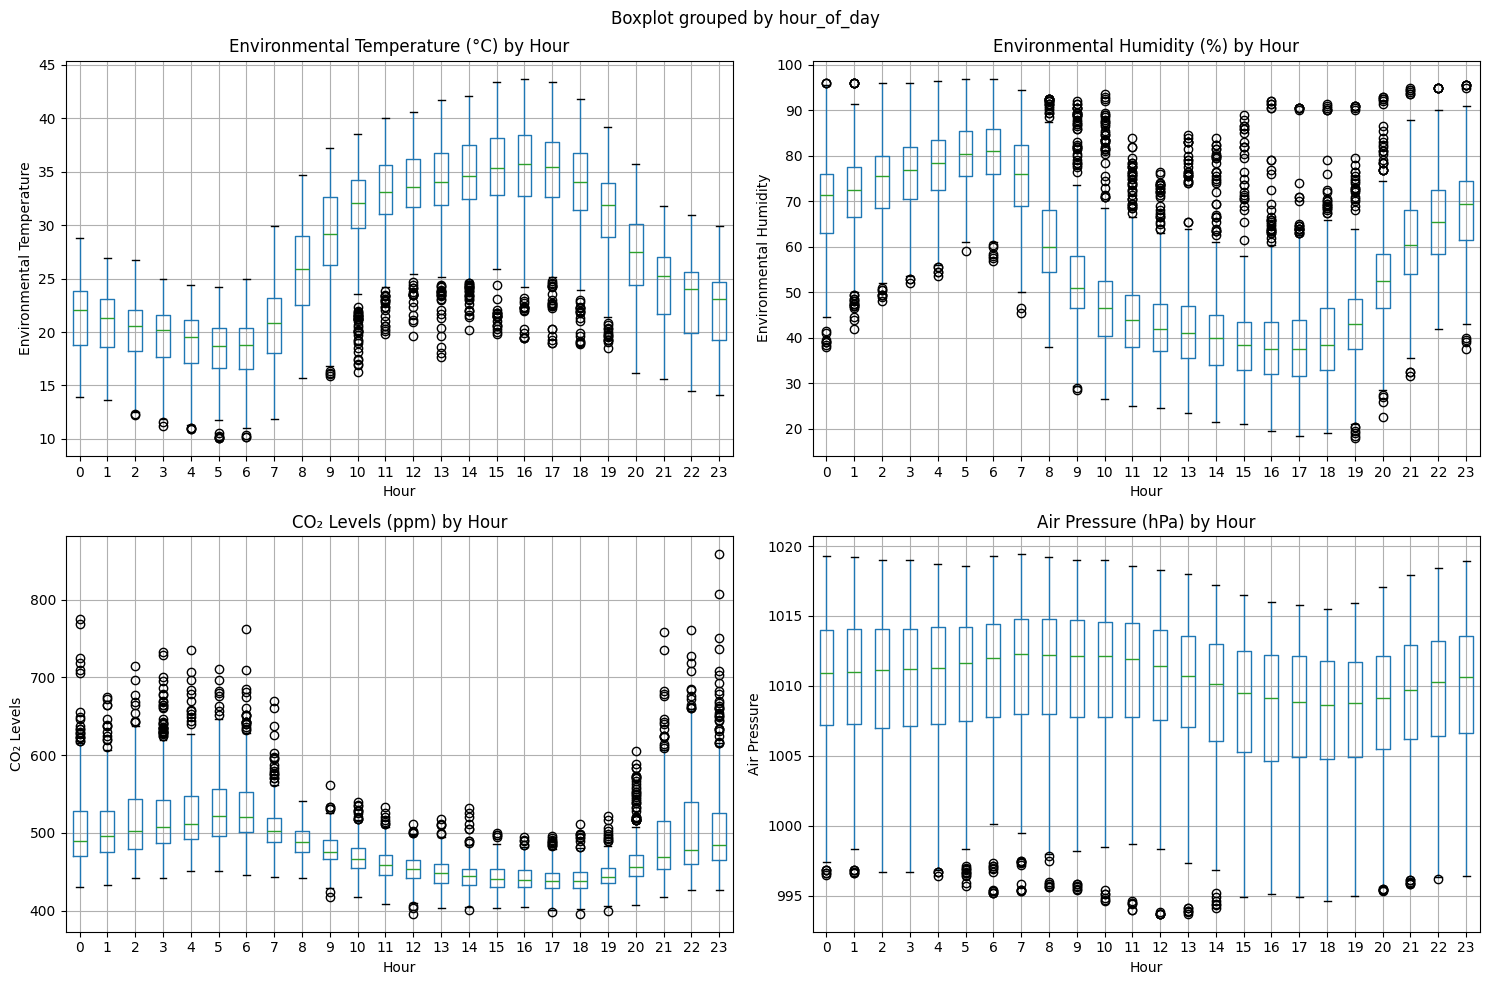

In [50]:
# Convert the date column to hour (if it exists)
if 'dt' in df.columns:  # change 'dt' to your actual column name
    df['timestamp'] = pd.to_datetime(df['dt'])
    df['hour_of_day'] = df['timestamp'].dt.hour
else:
    df['hour_of_day'] = 0  # if no time column, set a default hour

# List of columns to check (actual name + title)
env_features = [
    ('temperature_env', 'Environmental Temperature (°C)'),
    ('humidity_env', 'Environmental Humidity (%)'),
    ('co2_env', 'CO₂ Levels (ppm)'),
    ('pressure_env', 'Air Pressure (hPa)')
]

# Check which columns exist in the DataFrame
existing_features = [(col, title) for col, title in env_features if col in df.columns]

if not existing_features:
    print("No matching columns found in the DataFrame.")
else:
    # Plot the graphs
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for ax, (col, title) in zip(axes, existing_features):
        df.boxplot(column=col, by='hour_of_day', ax=ax)
        ax.set_title(f"{title} by Hour")
        ax.set_xlabel('Hour')
        ax.set_ylabel(title.split('(')[0].strip())

    # Hide empty graphs if there are fewer columns
    for ax in axes[len(existing_features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


# SOIL CONDITIONS BY HOUR

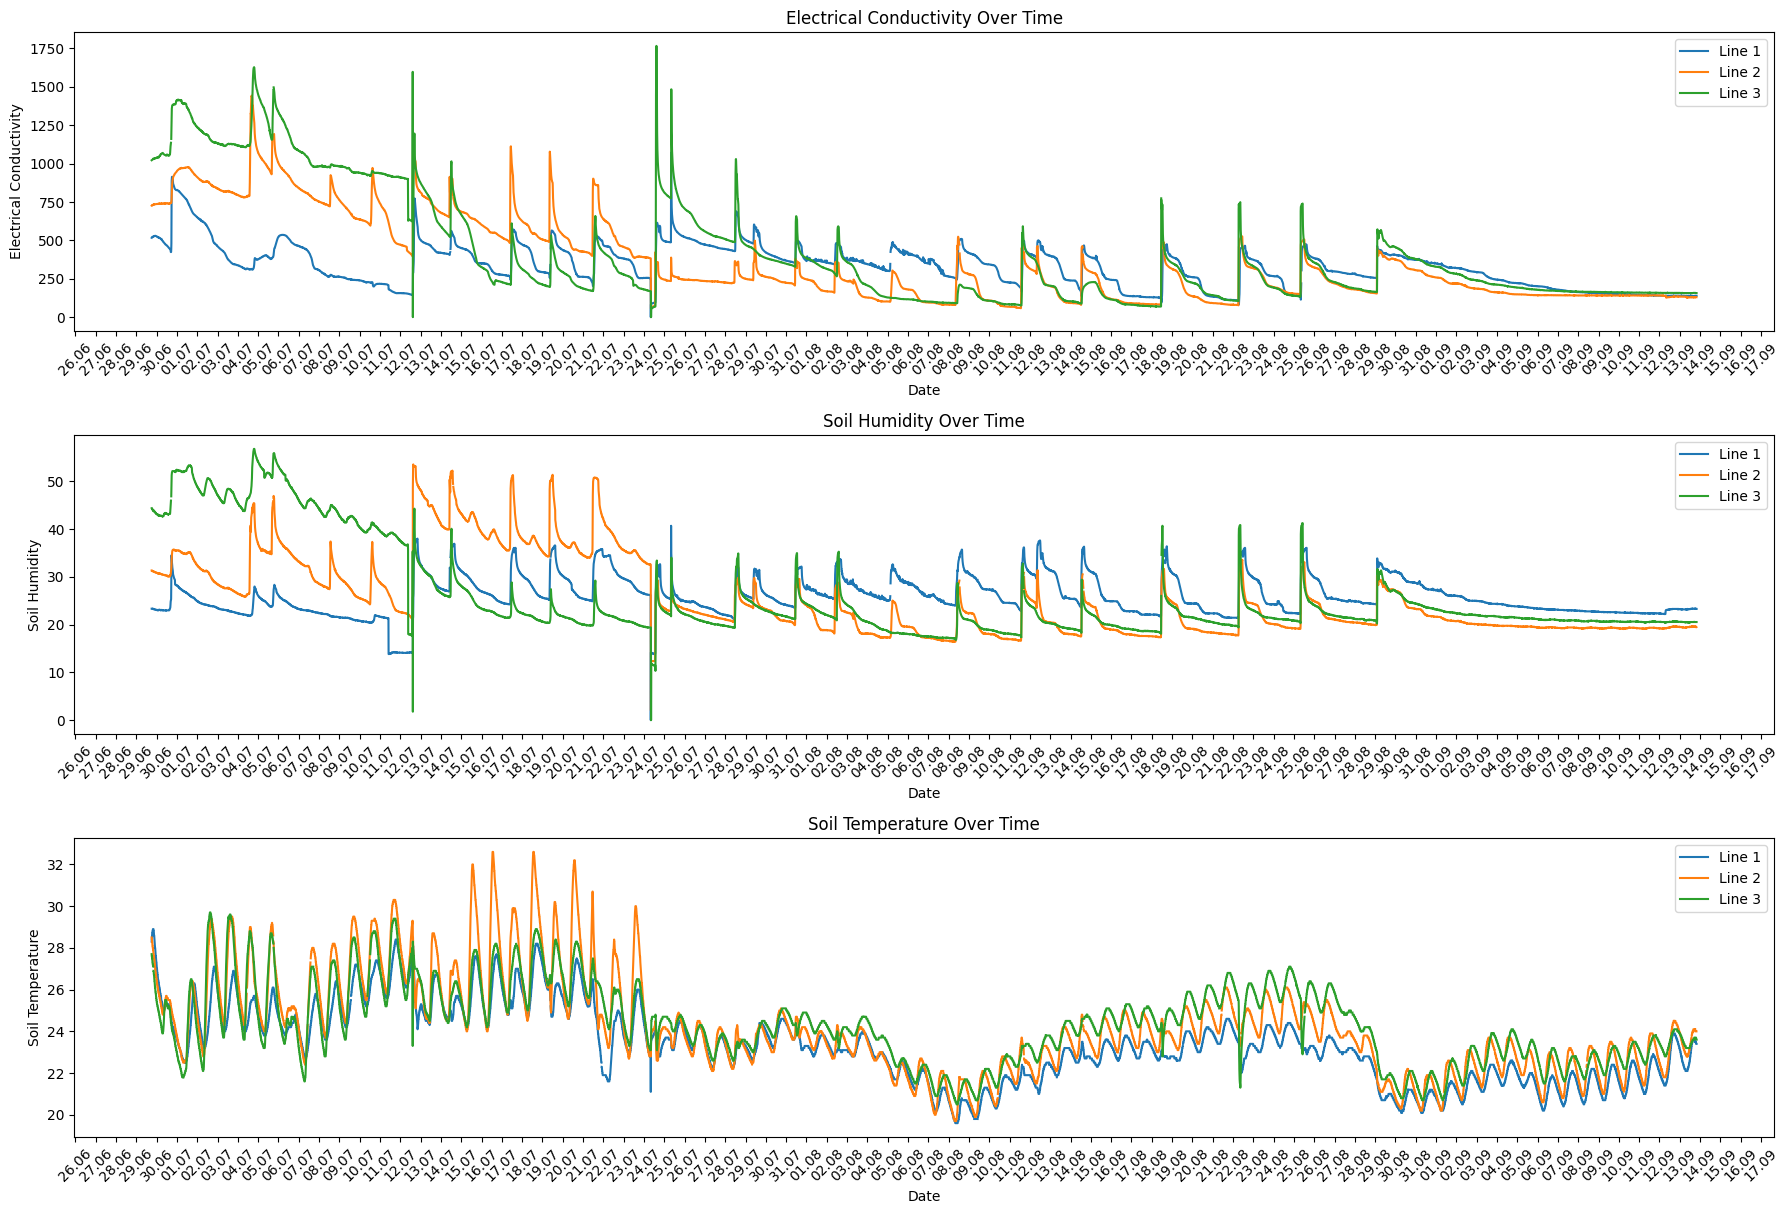

In [51]:
# Time series plot for each line's soil data (electrical_conductivity, humidity, temperature)
soil_lines = [1, 2, 3]
soil_features = [
    ('electrical_conductivity', 'Electrical Conductivity'),
    ('humidity', 'Soil Humidity'),
    ('temperature', 'Soil Temperature')
]

plt.figure(figsize=(18, 12))

for i, (feature, title) in enumerate(soil_features):
    plt.subplot(3, 1, i + 1)
    for line in soil_lines:
        col_name = f"{feature}_L{line}"
        if col_name in df.columns:
            plt.plot(pd.to_datetime(df['dt']), df[col_name], label=f'Line {line}')
    plt.title(f'{title} Over Time')
    plt.xlabel('Date')
    plt.ylabel(title)
    plt.legend()
    plt.tight_layout()
    # Set x-axis to show day and month only
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d.%m'))
    plt.xticks(rotation=45)

plt.show()

# WATER CONDITIONS BY HOUR

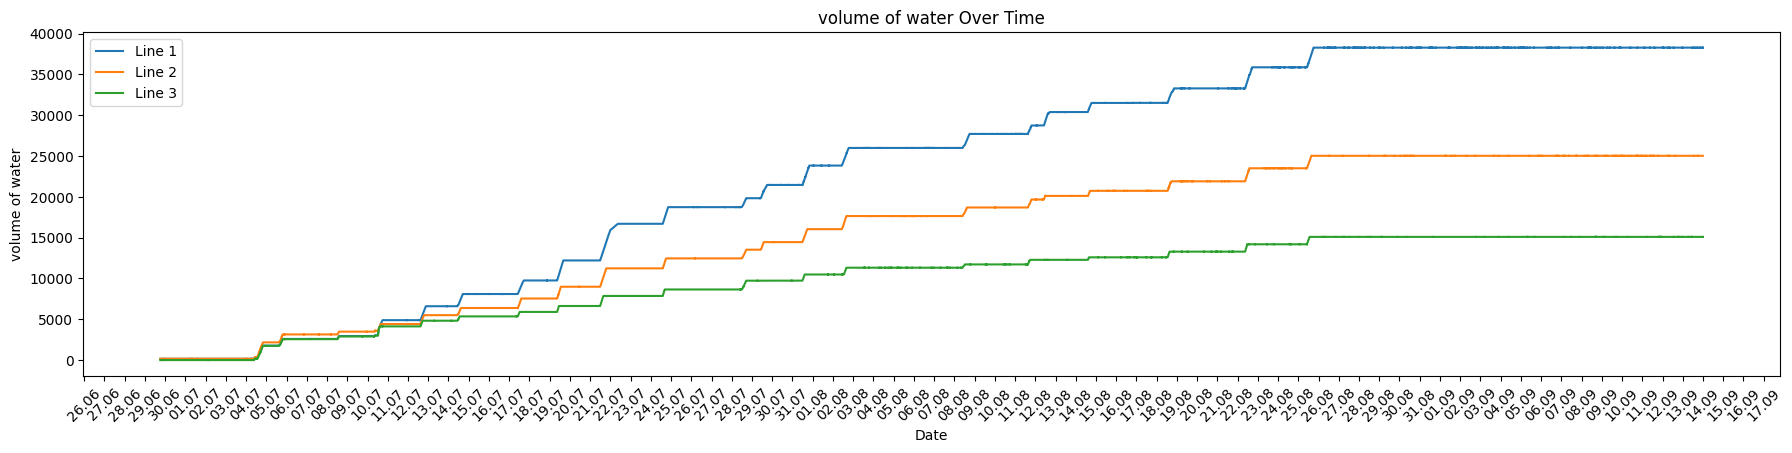

In [52]:
# Time series plot for each line's soil data (electrical_conductivity, humidity, temperature)
water_lines = [1, 2, 3]
water_features = [
    ('current_volume', 'volume of water'),]

plt.figure(figsize=(18, 12))

for i, (feature, title) in enumerate(water_features):
    plt.subplot(3, 1, i + 1)
    for line in water_lines:
        col_name = f"{feature}_L{line}"
        if col_name in df.columns:
            plt.plot(pd.to_datetime(df['dt']), df[col_name], label=f'Line {line}')
    plt.title(f'{title} Over Time')
    plt.xlabel('Date')
    plt.ylabel(title)
    plt.legend()
    plt.tight_layout()
    # Set x-axis to show day and month only
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d.%m'))
    plt.xticks(rotation=45)

plt.show()

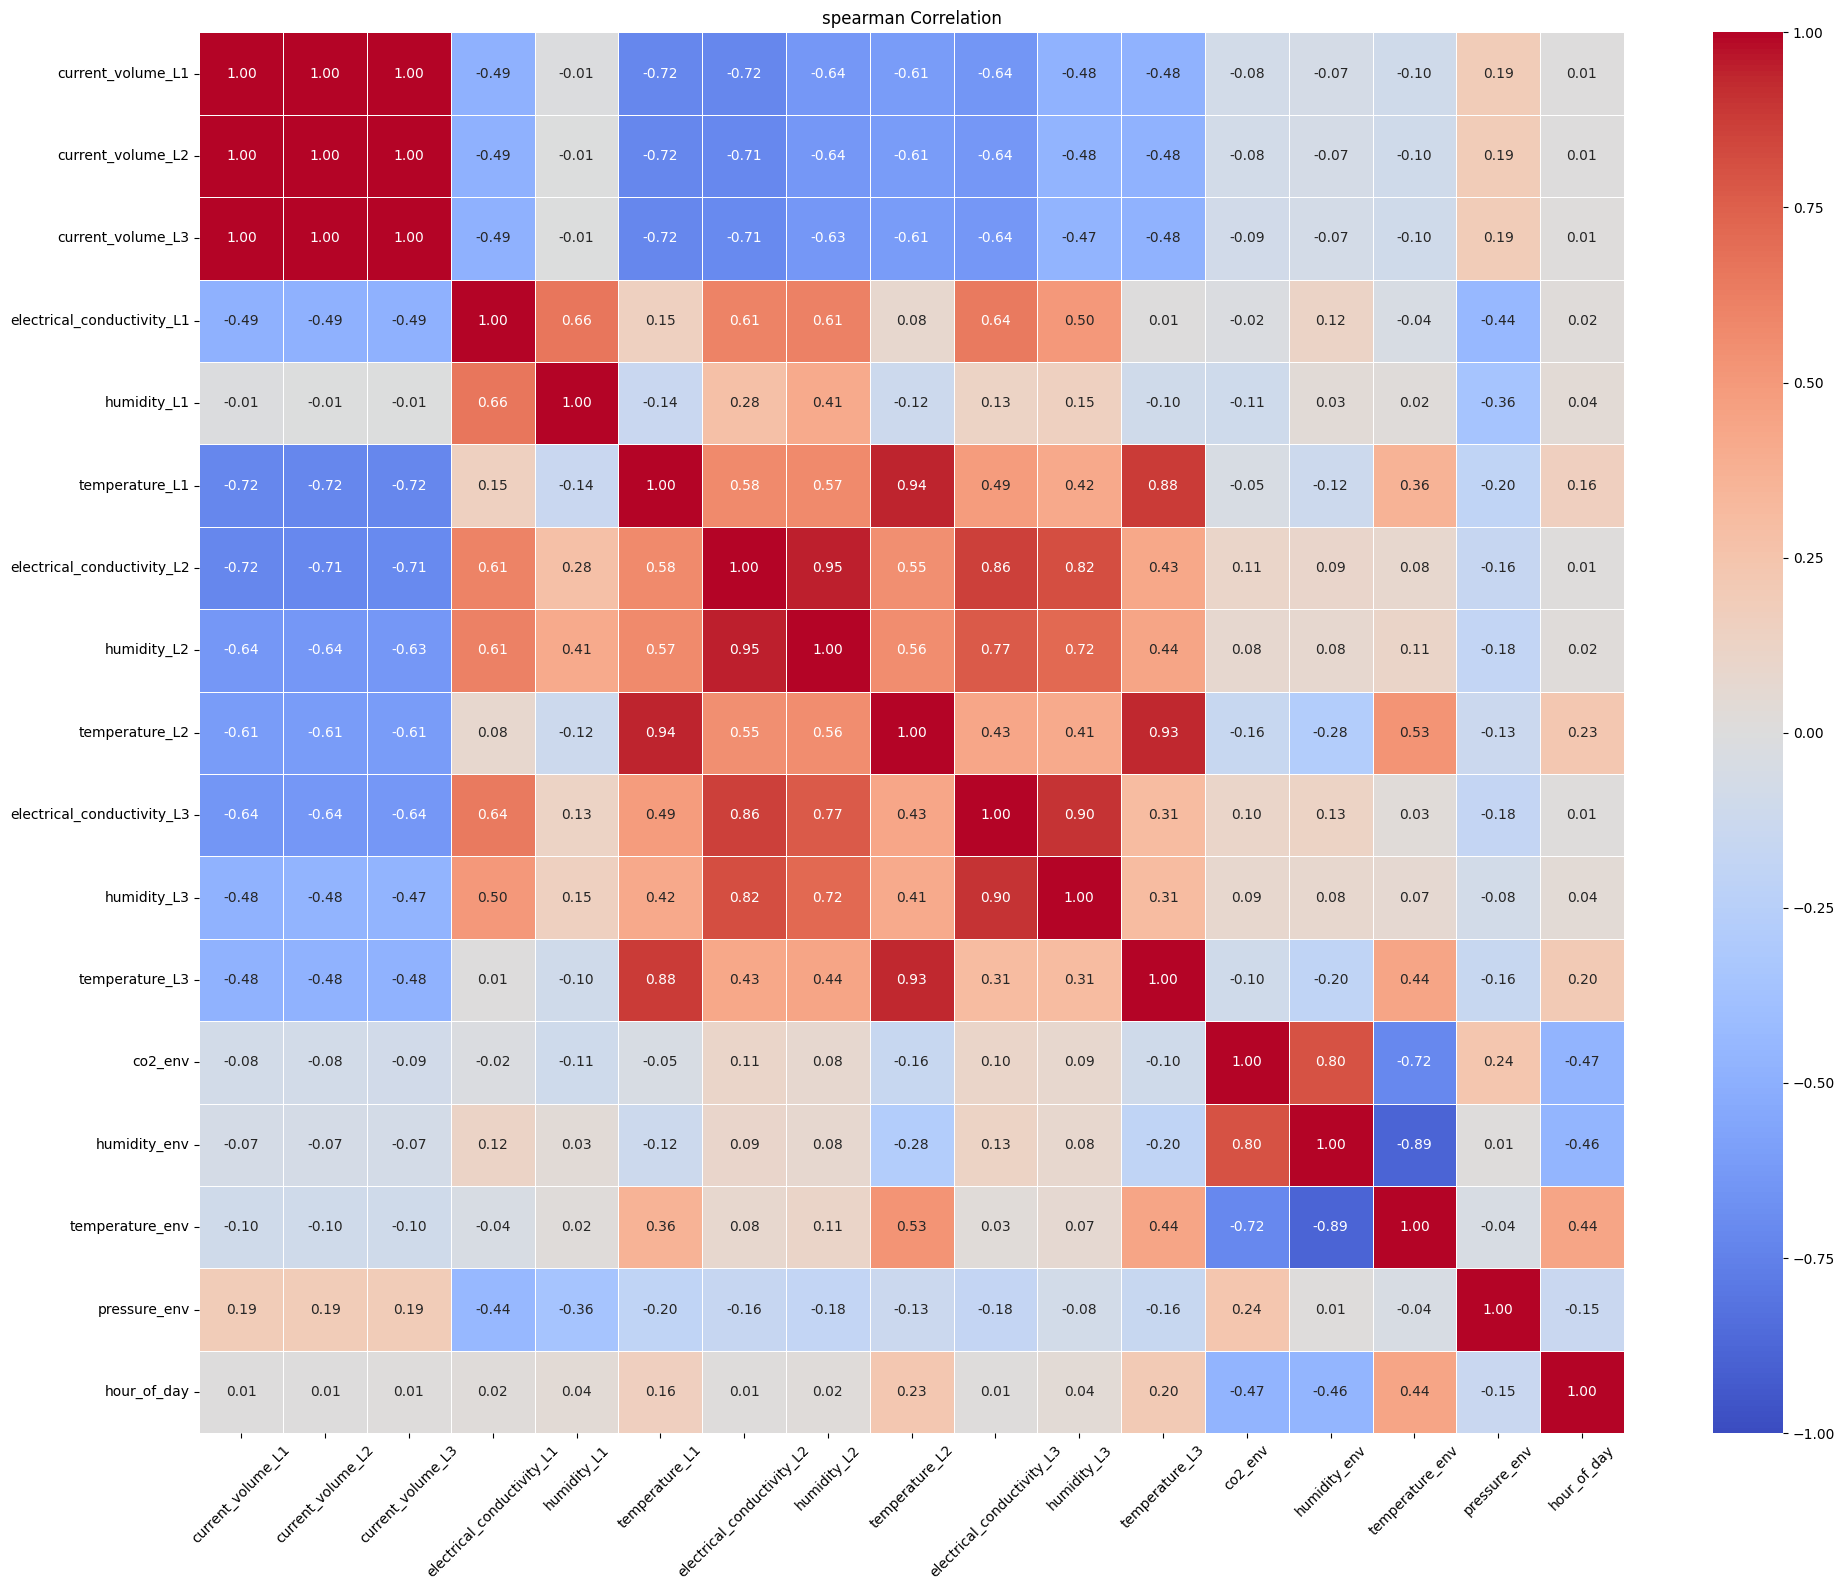

In [53]:
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if "yesterday" not in col]

# Compute Pearson correlations
pearson = df[numeric_cols].corr(method="spearman")

vmin, vmax = -1, 1

plt.figure(figsize=(20, 16))
sns.heatmap(
    pearson,
    vmin=vmin, vmax=vmax,
    cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5,
)
plt.title("spearman Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



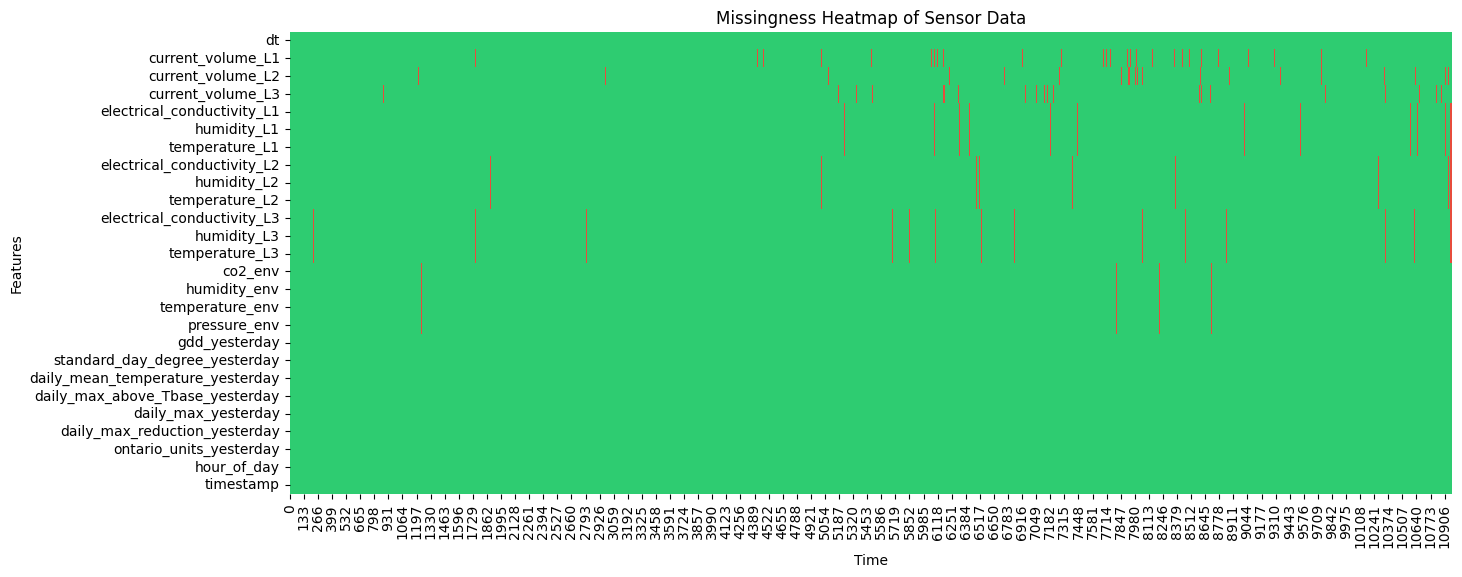

In [54]:
# Create a boolean mask of missing values (True = missing)
missing_mask = df.isnull()

# Plot heatmap (downsample if too big, e.g. resample to daily)
plt.figure(figsize=(15,6))
sns.heatmap(
    missing_mask.T,  # transpose: features on y-axis
    cbar=False,
    cmap=['#2ecc71', '#e74c3c']  # green = present, red = missing
)

plt.title("Missingness Heatmap of Sensor Data")
plt.xlabel("Time")
plt.ylabel("Features")
plt.show()

In [ ]:
# ensure dt is datetime, index and sorted
df['dt'] = pd.to_datetime(df['dt'], utc=False, errors='coerce')
df.set_index('dt', inplace=True)
df.sort_index(inplace=True)

In [58]:


# select numeric columns and convert to float to allow NaNs
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].astype(float).interpolate(method='time', limit_direction='both')

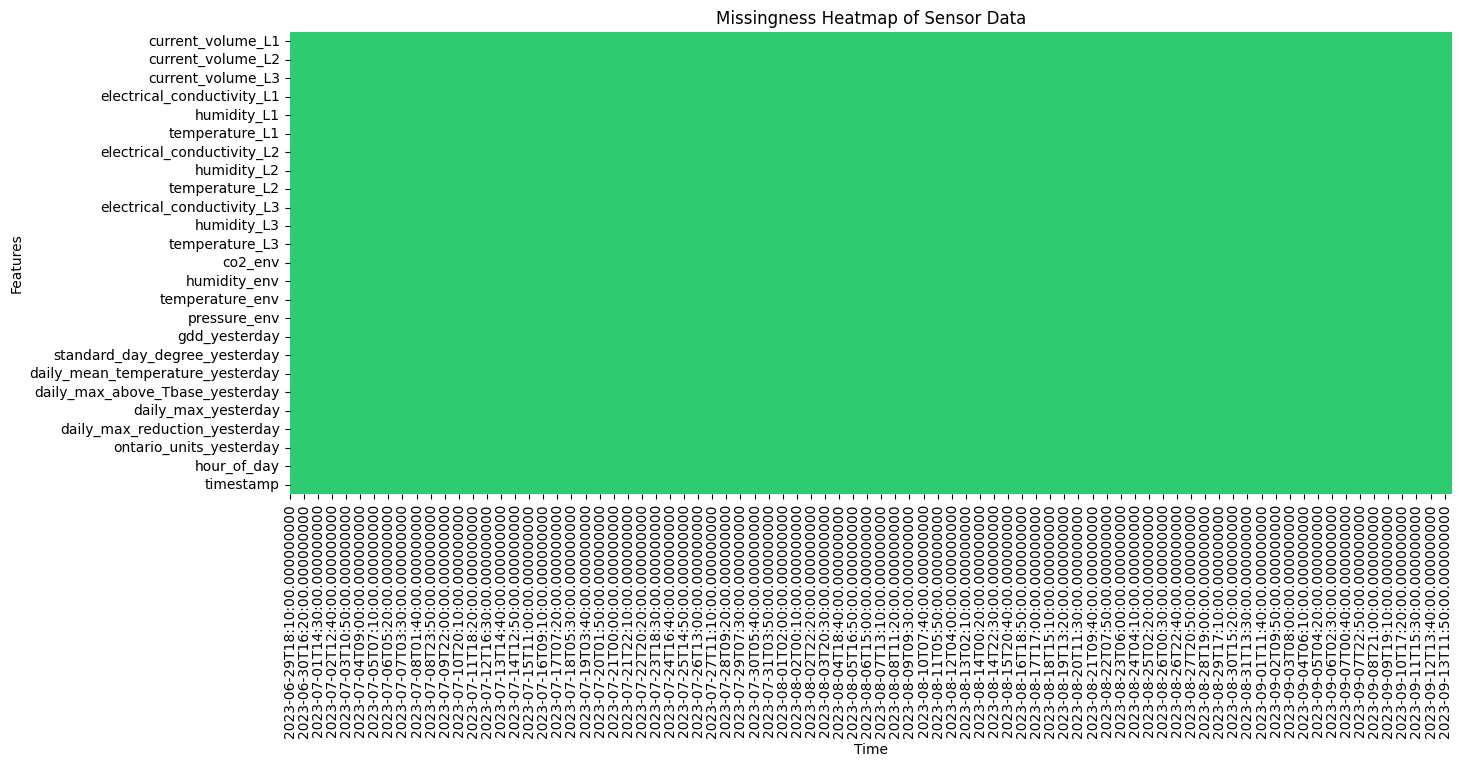

In [59]:
# Create a boolean mask of missing values (True = missing)
missing_mask = df.isnull()

# Plot heatmap (downsample if too big, e.g. resample to daily)
plt.figure(figsize=(15,6))
sns.heatmap(
    missing_mask.T,  # transpose: features on y-axis
    cbar=False,
    cmap=['#2ecc71', '#e74c3c']  # green = present, red = missing
)

plt.title("Missingness Heatmap of Sensor Data")
plt.xlabel("Time")
plt.ylabel("Features")
plt.show()

In [67]:
from plotly.subplots import make_subplots

import plotly.graph_objects as go

# Time series plot for each line's soil data (electrical_conductivity, humidity, temperature)
soil_lines = [1, 2, 3]
soil_features = [
    ('humidity', 'Soil Humidity'),
    ('electrical_conductivity', 'Electrical Conductivity'),
    ('temperature', 'Soil Temperature')
]

fig = make_subplots(rows=3, cols=1, subplot_titles=[title for _, title in soil_features])

for i, (feature, title) in enumerate(soil_features):
    for line in soil_lines:
        col_name = f"{feature}_L{line}"
        if col_name in df.columns:
            fig.add_trace(
                go.Scatter(x=df.index, y=df[col_name], mode='lines', name=f'Line {line} ({title})'),
                row=i+1, col=1
            )

fig.update_layout(
    height=900,
    title_text="Soil Conditions Over Time",
    showlegend=True,
    hovermode='x unified'
)

# Update x-axis for all subplots to show day and month
for i in range(1, 4):
    fig.update_xaxes(tickformat='%d.%m', row=i, col=1)

fig.show()

In [61]:
df = df.reset_index().rename(columns={'index': 'dt'})
df.to_csv('combined_data_NaN_filled.csv', index=False)  # Save the DataFrame with interpolated values to a CSV file

In [62]:
df = pd.read_csv('combined_data_NaN_filled.csv')
df['dt'] = pd.to_datetime(df['dt'])
env_cols = ['dt','co2_env', 'humidity_env', 'temperature_env', 'pressure_env'] 
line1_cols = ['current_volume_L1','electrical_conductivity_L1','humidity_L1','temperature_L1']
line2_cols = ['current_volume_L2','electrical_conductivity_L2','humidity_L2','temperature_L2']
line3_cols = ['current_volume_L3','electrical_conductivity_L3','humidity_L3','temperature_L3']

df1 = df[env_cols + line1_cols].copy()
df1['line'] = 'L100'
df1.rename(columns=lambda x: x.replace('_L1',''), inplace=True)

df2 = df[env_cols + line2_cols].copy()
df2['line'] = 'L60'
df2.rename(columns=lambda x: x.replace('_L2',''), inplace=True)

df3 = df[env_cols + line3_cols].copy()
df3['line'] = 'L30'
df3.rename(columns=lambda x: x.replace('_L3',''), inplace=True)

df_long = pd.concat([df1, df2, df3], ignore_index=True)

In [ ]:
df_long.to_csv('long_format_data.csv', index=False)  # Save the long format DataFrame to a CSV file